# Download and Process SNODAS Data

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rxr
import rasterio as rio
import pickle

import ee
import easysnowdata

### Initialize GEE

In [3]:
ee.Authenticate()


Successfully saved authorization token.


In [4]:
ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

### Download snodas data from GEE using Eric Gagliano's Easy Snow Data:

In [5]:
ucrb = pickle.load(open('../data/misc/ucrb.pkl', 'rb'))

In [10]:
ucrb.bounds

,minx,miny,maxx,maxy
0,-112.328642,35.558361,-105.626412,43.452183


In [12]:
ucrb.bounds['minx']

0   -112.328642
Name: minx, dtype: float64

In [15]:
from shapely.geometry import box

# Define bounding box coordinates (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = ucrb.bounds['minx'], ucrb.bounds['miny'], ucrb.bounds['maxx'], ucrb.bounds['maxy']
# Create the polygon
bbox_polygon = box(minx, miny, maxx, maxy)
# Make a polygon into a dataframe so it can have a crs
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs='EPSG:4326')


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/shapely/geometry/polygon.py:91: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return [float(c) for c in o]


#### Separately download years based on small grid shift in 2013 reported in documentation:

In [31]:
years = np.arange(2005, 2013, 1)

snodas_ds = easysnowdata.hydroclimatology.get_snodas(
    bbox_input=bbox_gdf,
    start_date=f"{years[0]}-04-01",
    end_date=f"{years[0]}-04-01",
    variables=["SWE"]
)

for year in years[1:]:
    snodas_temp = easysnowdata.hydroclimatology.get_snodas(
        bbox_input=bbox_gdf,
        start_date=f"{year}-04-01",
        end_date=f"{year}-04-01",
        variables=["SWE"])
    snodas_ds = xr.concat([snodas_ds, snodas_temp], dim='time')

In [36]:
years = np.arange(2013, 2022, 1)

snodas_ds2 = easysnowdata.hydroclimatology.get_snodas(
    bbox_input=bbox_gdf,
    start_date=f"{years[0]}-04-01",
    end_date=f"{years[0]}-04-01",
    variables=["SWE"]
)

for year in years[1:]:
    snodas_temp = easysnowdata.hydroclimatology.get_snodas(
        bbox_input=bbox_gdf,
        start_date=f"{year}-04-01",
        end_date=f"{year}-04-01",
        variables=["SWE"])
    snodas_ds2 = xr.concat([snodas_ds2, snodas_temp], dim='time')

<Axes: title={'center': 'time = 2021-04-01, spatial_ref = 0'}, xlabel='longitude', ylabel='latitude'>

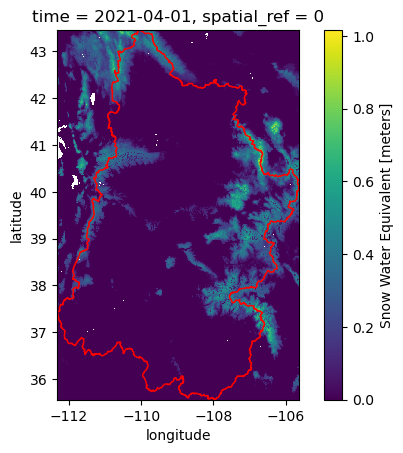

In [21]:
fig, ax = plt.subplots()
snodas_ds.SWE.plot(ax=ax)
ucrb.plot(ax=ax, facecolor='none', edgecolor='r')


In [72]:
print(snodas_ds.longitude[1].values)
print(snodas_ds2.longitude[1].values)

-112.31614198229575
-112.31614198229575


In [73]:
print(snodas_ds.latitude[1].values)
print(snodas_ds2.latitude[1].values)

43.43968346015428
43.43968346015428


#### The grids seem to be aligned, maybe Climate Engine/GEE aligned them?  
#### Can move forward with combining the 2 datasets:

In [39]:
snodas_ds_combined = xr.concat([snodas_ds, snodas_ds2], dim='time')

In [40]:
snodas_ds_combined

<xarray.Dataset> Size: 52MB
Dimensions:      (time: 17, latitude: 947, longitude: 804)
Coordinates:
  * time         (time) datetime64[ns] 136B 2005-04-01 2006-04-01 ... 2021-04-01
  * longitude    (longitude) float64 6kB -112.3 -112.3 -112.3 ... -105.6 -105.6
  * latitude     (latitude) float64 8kB 43.45 43.44 43.43 ... 35.58 35.57 35.56
    spatial_ref  int64 8B 0
Data variables:
    SWE          (time, latitude, longitude) float32 52MB 0.0 0.0 ... 0.0 0.0
Attributes:
    title:                Snow Data Assimilation System (SNODAS)
    institution:          National Operational Hydrologic Remote Sensing Cent...
    source:               Google Earth Engine (Climate Engine Org collection)
    spatial_resolution:   1 km
    temporal_resolution:  Daily
    coverage:             Continental United States, Alaska, and Hawaii
    data_citation:        Barrett, Andrew. 2003. National Operational Hydrolo...
    license:              NOAA data, information, and products, regardless of...

### Clip the combined data to UCRB outline:

In [42]:
ucrb.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
snodas_ds_combined_clip = snodas_ds_combined.rio.clip(ucrb.geometry)

<Axes: title={'center': 'time = 2005-04-01, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

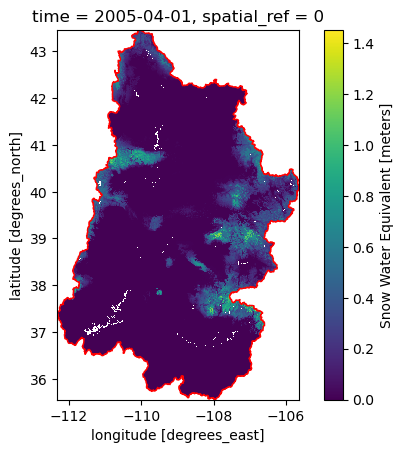

In [45]:
fig, ax = plt.subplots()
snodas_ds_combined_clip.SWE[0].plot(ax=ax)
ucrb.plot(ax=ax, facecolor='none', edgecolor='r')


#### Check the resolution in m by first transforming to utm:

In [54]:
snodas_utm = snodas_ds_combined_clip.rio.reproject('epsg:32612')

In [76]:
print(snodas_utm.x[1].values - snodas_utm.x[0].values)
print(snodas_utm.y[0].values - snodas_utm.y[1].values)

843.8387829838903
843.8387829838321


### reproject and resample to match the resolution and crs of reanalysis data:

In [77]:
swe_reanalysis = xr.open_dataset('../data/reanalysis/swe_reanalysis_ucrb.nc')

In [57]:
snodas_match = snodas_ds_combined_clip.rio.reproject_match(swe_reanalysis.SWE_Post)

In [58]:
snodas_match

<xarray.Dataset> Size: 182MB
Dimensions:      (time: 17, x: 1508, y: 1776)
Coordinates:
  * time         (time) datetime64[ns] 136B 2005-04-01 2006-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
  * x            (x) float64 12kB -112.3 -112.3 -112.3 ... -105.6 -105.6 -105.6
  * y            (y) float64 14kB 35.56 35.57 35.57 35.58 ... 43.44 43.45 43.45
Data variables:
    SWE          (time, y, x) float32 182MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:                Snow Data Assimilation System (SNODAS)
    institution:          National Operational Hydrologic Remote Sensing Cent...
    source:               Google Earth Engine (Climate Engine Org collection)
    spatial_resolution:   1 km
    temporal_resolution:  Daily
    coverage:             Continental United States, Alaska, and Hawaii
    data_citation:        Barrett, Andrew. 2003. National Operational Hydrolo...
    license:              NOAA data, information, and products, regardless of...

In [79]:
snodas_match_rename = snodas_match.rename_dims(dims_dict={'time':'Year'})

In [102]:
snodas_match_rename2 = snodas_match_rename.rename_vars({'time':'Year'})

In [82]:
snodas_match_rename

<xarray.Dataset> Size: 182MB
Dimensions:      (Year: 17, x: 1508, y: 1776)
Coordinates:
  * time         (Year) datetime64[ns] 136B 2005-04-01 2006-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
  * x            (x) float64 12kB -112.3 -112.3 -112.3 ... -105.6 -105.6 -105.6
  * y            (y) float64 14kB 35.56 35.57 35.57 35.58 ... 43.44 43.45 43.45
Dimensions without coordinates: Year
Data variables:
    SWE          (Year, y, x) float32 182MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:                Snow Data Assimilation System (SNODAS)
    institution:          National Operational Hydrologic Remote Sensing Cent...
    source:               Google Earth Engine (Climate Engine Org collection)
    spatial_resolution:   1 km
    temporal_resolution:  Daily
    coverage:             Continental United States, Alaska, and Hawaii
    data_citation:        Barrett, Andrew. 2003. National Operational Hydrolo...
    license:              NOAA data, information, and products, regardless of...

In [93]:
snodas_match_rename2

<xarray.Dataset> Size: 182MB
Dimensions:      (Year: 17, x: 1508, y: 1776)
Coordinates:
  * Year         (Year) datetime64[ns] 136B 2005-04-01 2006-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
  * x            (x) float64 12kB -112.3 -112.3 -112.3 ... -105.6 -105.6 -105.6
  * y            (y) float64 14kB 35.56 35.57 35.57 35.58 ... 43.44 43.45 43.45
Data variables:
    SWE          (Year, y, x) float32 182MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:                Snow Data Assimilation System (SNODAS)
    institution:          National Operational Hydrologic Remote Sensing Cent...
    source:               Google Earth Engine (Climate Engine Org collection)
    spatial_resolution:   1 km
    temporal_resolution:  Daily
    coverage:             Continental United States, Alaska, and Hawaii
    data_citation:        Barrett, Andrew. 2003. National Operational Hydrolo...
    license:              NOAA data, information, and products, regardless of...

In [105]:
Years = np.arange(2005, 2022, 1)
Years

array([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021])

In [109]:
from datetime import datetime

In [111]:
snodas_match_rename2['Year'] = snodas_match_rename2['Year'].dt.year
#snodas_match_rename2.Year.datetime.year

In [112]:
snodas_match_rename2

<xarray.Dataset> Size: 182MB
Dimensions:      (Year: 17, x: 1508, y: 1776)
Coordinates:
  * Year         (Year) int64 136B 2005 2006 2007 2008 ... 2018 2019 2020 2021
    spatial_ref  int64 8B 0
  * x            (x) float64 12kB -112.3 -112.3 -112.3 ... -105.6 -105.6 -105.6
  * y            (y) float64 14kB 35.56 35.57 35.57 35.58 ... 43.44 43.45 43.45
Data variables:
    SWE          (Year, y, x) float32 182MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:                Snow Data Assimilation System (SNODAS)
    institution:          National Operational Hydrologic Remote Sensing Cent...
    source:               Google Earth Engine (Climate Engine Org collection)
    spatial_resolution:   1 km
    temporal_resolution:  Daily
    coverage:             Continental United States, Alaska, and Hawaii
    data_citation:        Barrett, Andrew. 2003. National Operational Hydrolo...
    license:              NOAA data, information, and products, regardless of...

In [96]:
snodas_match_rename2_t = snodas_match_rename2.transpose('y', 'x', 'Year')[['y', 'x', 'Year']]

In [101]:
snodas_match_rename2_t

<xarray.Dataset> Size: 26kB
Dimensions:      (y: 1776, x: 1508, Year: 17)
Coordinates:
  * y            (y) float64 14kB 35.56 35.57 35.57 35.58 ... 43.44 43.45 43.45
  * x            (x) float64 12kB -112.3 -112.3 -112.3 ... -105.6 -105.6 -105.6
  * Year         (Year) datetime64[ns] 136B 2005-04-01 2006-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
Data variables:
    *empty*
Attributes:
    title:                Snow Data Assimilation System (SNODAS)
    institution:          National Operational Hydrologic Remote Sensing Cent...
    source:               Google Earth Engine (Climate Engine Org collection)
    spatial_resolution:   1 km
    temporal_resolution:  Daily
    coverage:             Continental United States, Alaska, and Hawaii
    data_citation:        Barrett, Andrew. 2003. National Operational Hydrolo...
    license:              NOAA data, information, and products, regardless of...

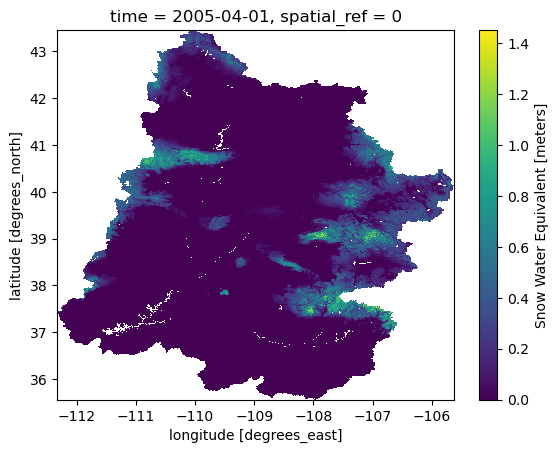

In [60]:
snodas_match.SWE[0].plot()

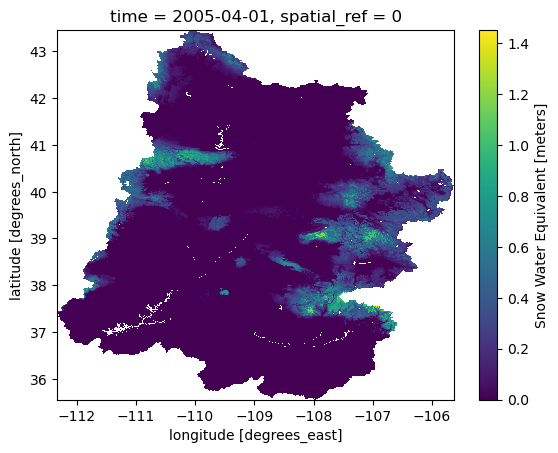

In [61]:
snodas_ds_combined_clip.SWE[0].plot()

In [113]:
snodas_match_rename2.to_netcdf('../data/snodas/snodas_swe_ucrb_match_2005_2021.nc')

In [33]:
# snodas_scaled = snodas_scaled.rename({'lat':'y','lon':'x'})
# snodas_scaled = snodas_scaled.rio.set_spatial_dims('y','x',inplace=True)
# snodas_scaled = snodas_scaled.sortby("x").sortby("y")